# **Introduction**

CAPM and Fama French 3-Factor regression analysis for different tickers in the same index.

**Index: Euronext 100 (^N100)**
- (INGA.AS) ING Groep N.V.
- (KER.PA) Kering SA
- (HO.PA) Thales S.A.
- (GALP.LS) Galp Energia
- (IPN.PA) Ipsen S.A.

# **Table of Contents**


1. Organising all the pip installs and library imports
2. Analysis for (INGA.AS) ING Groep N.V.
3. Analysis for (KER.PA) Kering SA
4. Analysis for (HO.PA) Thales S.A.
5. Analysis for (GALP.LS) Galp Energia
6. Analysis for (IPN.PA) Ipsen S.A.

# **1. Organising all the pip installs and library imports**

In [1]:
# Pip installs
!pip install yfinance --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install scipy --quiet
!pip install pandas_datareader --quiet
!pip install seaborn --quiet
!pip install statsmodels --quiet


In [2]:
# Importing libraries
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import statsmodels.api as sm
import matplotlib.style as style
import seaborn as sns
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings("ignore")

# **2. Analysis for (INGA.AS) ING Groep N.V.**

### a) Importing and plotting price data from Yahoo Finance

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


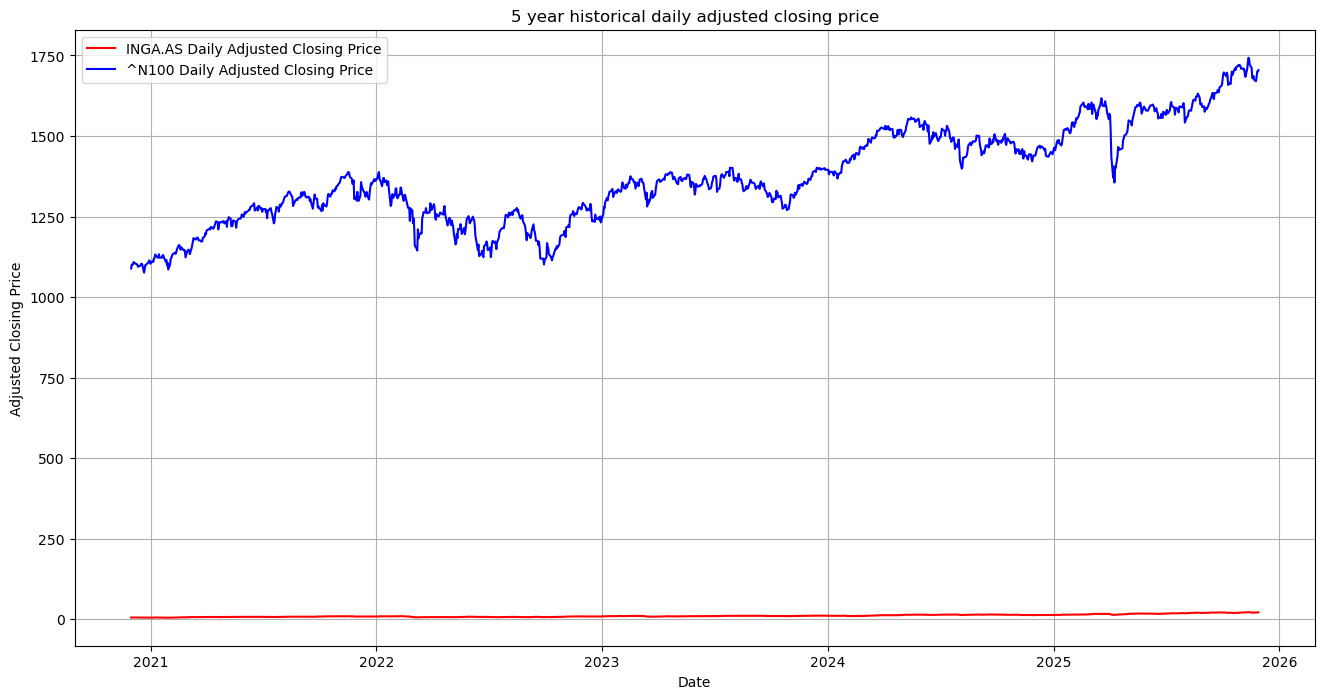

In [3]:
# Importing the data using yfinance
df = pd.DataFrame(yf.download("INGA.AS", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()
index = pd.DataFrame(yf.download("^N100", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the data
plt.figure(figsize = (16, 8))
plt.grid(True)
plt.ylabel("Adjusted Closing Price")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price")
plt.plot(df["Adj Close"], label = "INGA.AS Daily Adjusted Closing Price", color="red")
plt.plot(index["Adj Close"], label = "^N100 Daily Adjusted Closing Price", color="blue")
plt.legend()
plt.show()

### b) CAPM Analysis

I am going to use OLS regression for CAPM analsysis to get the the CAPM Model Summary table and then plot the results with a line of regression. For this specific purpose I will be using the risk free rate = 3%.

$$E(R_i) = R_f + \beta_i(E(R_m) - R_f)$$

[*********************100%***********************]  2 of 2 completed


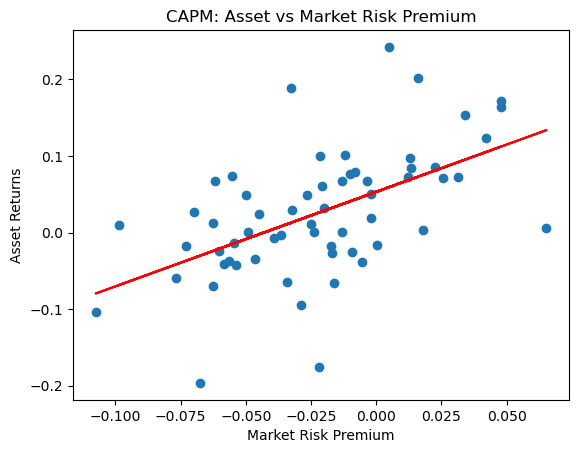

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     24.69
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           6.28e-06
Time:                        16:06:11   Log-Likelihood:                 74.990
No. Observations:                  60   AIC:                            -146.0
Df Residuals:                      58   BIC:                            -141.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0532      0.011      5.021      0.0

In [4]:
# Getting Data from Yahoo Finance 
asset_ticker = "INGA.AS"
index = "^N100"
df = yf.download([asset_ticker, index], start= "2020-11-30", end= "2025-11-30", auto_adjust=False)[["Adj Close"]].dropna()

# Renaming columns and resampling data from daily to monthly
x = df["Adj Close"].rename(columns={asset_ticker: "asset",
 index: "market"}) \
 .resample("ME") \
 .last() \
 .pct_change() \
 .dropna()

# Defining x and y
y = x.pop("asset")
x["market"] = x["market"] - 0.03
x = sm.add_constant(x)
capm_model = sm.OLS(y, x).fit()


# Plotting market risk premium (x) and asset returns (y)
asset_returns = y
market_risk_premium = x["market"]
plot_x = sm.add_constant(market_risk_premium)
predict_y = capm_model.predict(plot_x)
plt.figure()
plt.scatter(market_risk_premium, asset_returns)
plt.plot(market_risk_premium, predict_y, color="red")
plt.xlabel("Market Risk Premium")
plt.ylabel("Asset Returns")
plt.title("CAPM: Asset vs Market Risk Premium")
plt.show()

print(capm_model.summary())

### CAPM Conclusions

- R-squared of 0.299 indicates that market fluctuations account for only 30% of ING"s results.
- Beta of (1.1235) indicates that ING is a little more volatile than the N100.
- p-value < 0.001 suggests that this is a good model.
- However, the market index does not account for INGs unique risk. These include Factors related to the banking industry, changes in regulations, credit crises, or business-specific.

### c) Fama French 3-Factor Analysis

I am going to conduct Fama French 3-Factor regression analysis. I will retrieve and use Fama French factors using the datareader. For this specific purpose I will be using the risk free rate = 3%.

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,M}(R_{M,t} - R_{f,t}) + \beta_{i,SMB}SMB_t + \beta_{i,HML}HML_t + \epsilon_{i,t}$$

In [5]:
# Getting data from Yahoo Finance
data_monthly = yf.download("INGA.AS", start="2020-11-30", end="2025-11-30", interval="1mo", auto_adjust=False)
data_monthly.columns = data_monthly.columns.get_level_values(0)
data_monthly = data_monthly[["Adj Close"]].dropna()

# calculating percentage returns
data_monthly["Return"] = data_monthly["Adj Close"].pct_change() * 100
data_monthly = data_monthly.dropna()

# Retrieving Fama French Factors
ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="2020-11-30", end="2025-11-30")
ff_monthly = ff[0].copy()

# Converting index to datetime and merging datasets
ff_monthly.index = ff_monthly.index.to_timestamp()
merged_data = ff_monthly.merge(data_monthly[["Return"]], left_index=True, right_index=True, how="inner")

# Calculating market risk premium
merged_data["Excess_Return"] = merged_data["Return"] - 0.03

# Regression Analysis
# CHANGE: Defined x and y separately and then fit the model
x = sm.add_constant(merged_data[["Mkt-RF", "SMB", "HML"]])
y = merged_data["Excess_Return"]
fama_model = sm.OLS(y, x).fit()

print(fama_model.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     8.507
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           9.81e-05
Time:                        16:06:11   Log-Likelihood:                -198.88
No. Observations:                  59   AIC:                             405.8
Df Residuals:                      55   BIC:                             414.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3668      1.008      1.356      0.1

### Fama French Conclusions

- The model substantially explains the excess returns of INGA.AS during the 58-month period.
- A beta of 0.7814, which indicates a reasonably defensive stock, and a coefficient of 0.9638, which confirms strong value stock characteristics
- The stock shows highly substantial positive exposure to both the Market Risk Factor (Mkt-RF) and the Value Factor (HML).
- There is no statistically significant exposure to the Size Factor (SMB).
- The stock produced a positive monthly Jensen's Alpha of 1.3995%, but this outperformance is not statistically significant (p=0.177), indicating that the apparent outperformance may have been the result of chance.

# **3. Analysis for (KER.PA) Kering SA.**

### a) Importing and plotting price data from Yahoo Finance

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


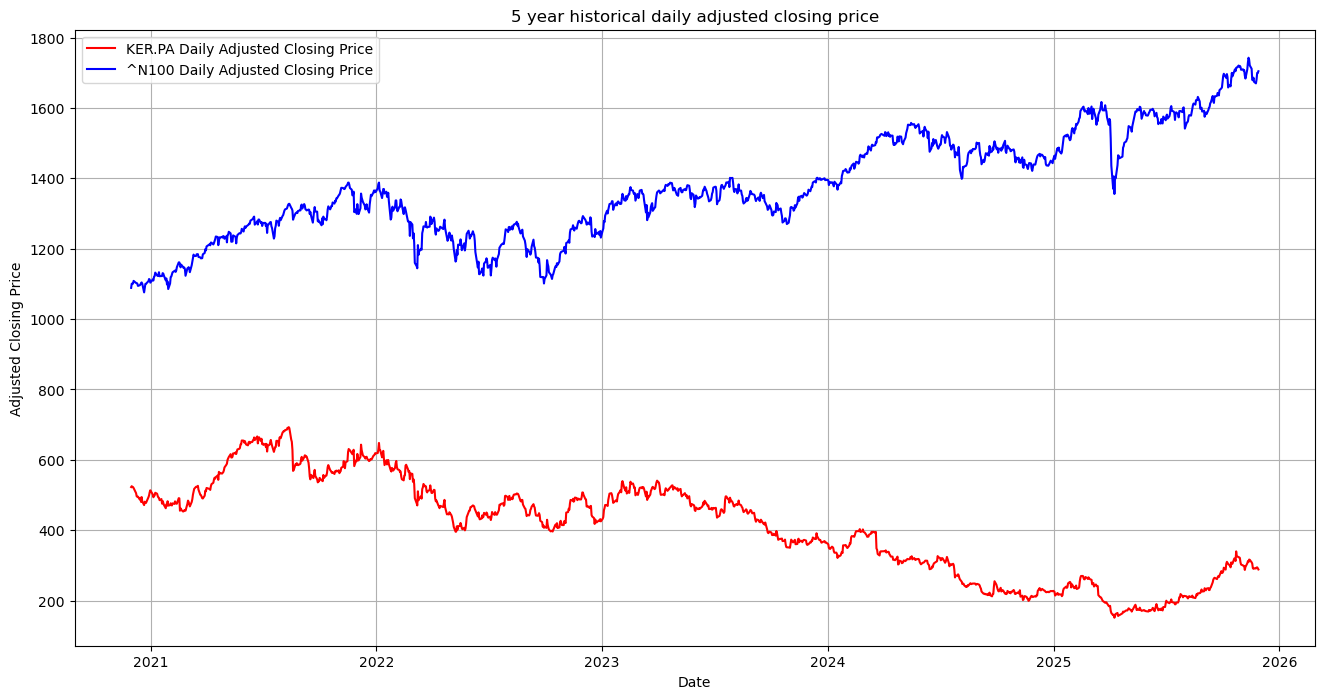

In [6]:
# Importing the data using yfinance
df = pd.DataFrame(yf.download("KER.PA", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()
index = pd.DataFrame(yf.download("^N100", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the data
plt.figure(figsize = (16, 8))
plt.grid(True)
plt.ylabel("Adjusted Closing Price")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price")
plt.plot(df["Adj Close"], label = "KER.PA Daily Adjusted Closing Price", color="red")
plt.plot(index["Adj Close"], label = "^N100 Daily Adjusted Closing Price", color="blue")
plt.legend()
plt.show()

### b) CAPM Analysis

I am going to use OLS regression for CAPM analsysis to get the the CAPM Model Summary table and then plot the results with a line of regression. For this specific purpose I will be using the risk free rate = 3%.

$$E(R_i) = R_f + \beta_i(E(R_m) - R_f)$$

[*********************100%***********************]  2 of 2 completed


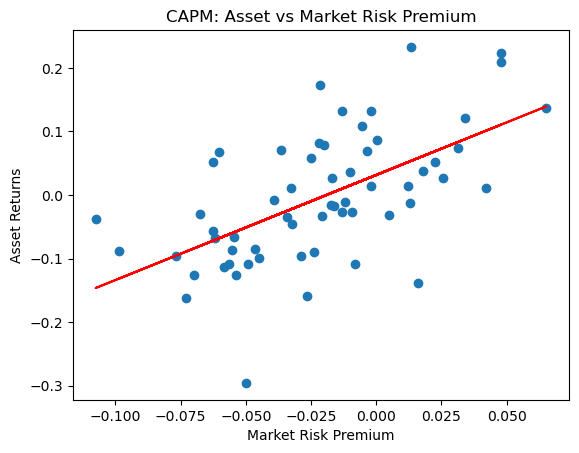

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     31.26
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           6.37e-07
Time:                        16:06:12   Log-Likelihood:                 64.501
No. Observations:                  60   AIC:                            -125.0
Df Residuals:                      58   BIC:                            -120.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0316      0.013      2.501      0.0

In [7]:
# Getting Data from Yahoo Finance
asset_ticker = "KER.PA"
index = "^N100"
df = yf.download([asset_ticker, index], start= "2020-11-30", end= "2025-11-30", auto_adjust=False)[["Adj Close"]].dropna()

# Renaming columns and resampling data from daily to monthly
x = df["Adj Close"].rename(columns={asset_ticker: "asset",
 index: "market"}) \
 .resample("ME") \
 .last() \
 .pct_change() \
 .dropna()

# Defining x and y
y = x.pop("asset")
x["market"] = x["market"] - 0.03
x = sm.add_constant(x)
capm_model = sm.OLS(y, x).fit()


# Plotting market risk premium (x) and asset returns (y)
asset_returns = y
market_risk_premium = x["market"]
plot_x = sm.add_constant(market_risk_premium)
predict_y = capm_model.predict(plot_x)
plt.figure()
plt.scatter(market_risk_premium, asset_returns)
plt.plot(market_risk_premium, predict_y, color="red")
plt.xlabel("Market Risk Premium")
plt.ylabel("Asset Returns")
plt.title("CAPM: Asset vs Market Risk Premium")
plt.show()

print(capm_model.summary())

### CAPM Conclusions

- The asset (KER.PA) shows a positive and statistically significant beta.
- According to this figure, the asset's excess return (Asset Returns) is predicted to fluctuate by 1.6540% for every 1% change in the market's excess return (Market Risk Premium).
- The asset has a larger systematic risk and is more volatile than the market as a whole because Beta>1. This beta is very significant, as shown by the strong t-statistic of 5.591 and the small P-value (0.000).
- The R-Squared of 0.350 suggests that the market's fluctuations account for around 35% of the asset's return variability, with firm-specific (unsystematic) risk accounting for the remaining 65%.

### c) Fama French 3-Factor Analysis

I am going to conduct Fama French 3-Factor regression analysis. I will retrieve and use Fama French factors using the datareader. For this specific purpose I will be using the risk free rate = 3%.

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,M}(R_{M,t} - R_{f,t}) + \beta_{i,SMB}SMB_t + \beta_{i,HML}HML_t + \epsilon_{i,t}$$

In [8]:
# Getting data from Yahoo Finance
data_monthly = yf.download("KER.PA", start="2020-11-30", end="2025-11-30", interval="1mo", auto_adjust=False)
data_monthly.columns = data_monthly.columns.get_level_values(0)
data_monthly = data_monthly[["Adj Close"]].dropna()

# calculating percentage returns
data_monthly["Return"] = data_monthly["Adj Close"].pct_change() * 100
data_monthly = data_monthly.dropna()

# Retrieving Fama French Factors
ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="2020-11-30", end="2025-11-30")
ff_monthly = ff[0].copy()

# Converting index to datetime and merging datasets
ff_monthly.index = ff_monthly.index.to_timestamp()
merged_data = ff_monthly.merge(data_monthly[["Return"]], left_index=True, right_index=True, how="inner")

# Calculating market risk premium
merged_data["Excess_Return"] = merged_data["Return"] - 0.03

# Regression Analysis
x = sm.add_constant(merged_data[["Mkt-RF", "SMB", "HML"]])
y = merged_data["Excess_Return"]
fama_model = sm.OLS(y, x).fit()

print(fama_model.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     8.783
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           7.47e-05
Time:                        16:06:13   Log-Likelihood:                -210.55
No. Observations:                  59   AIC:                             429.1
Df Residuals:                      55   BIC:                             437.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8383      1.228     -1.496      0.1

### Fama French Conclusions

- According to this OLS regression, the model accounts for around 32.2% (R-squared = 0.322) of the volatility in the excess returns of the stock.
- The relatively tiny (F-statistic) of 9.78×10−5 (less than 0.05) indicates that the model is statistically significant overall.
- Kering's returns appear to be sensitive to the market as a whole (a beta 1.3438 larger than 1), which is statistically significant.
- On the other hand, the Size (SMB) and Value (HML) factors' coefficients, at -0.6043 and -0.1541, respectively, are not statistically significant ( of 0.148 and 0.585), suggesting that Kering's excess returns are not meaningfully explained by whether it acts like a small-cap or large-cap company or like a high book-to-market or low book-to-market stock during this timeframe.

# **4. Analysis for (HO.PA) Thales S.A**

### a) Importing and plotting price data from Yahoo Finance

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


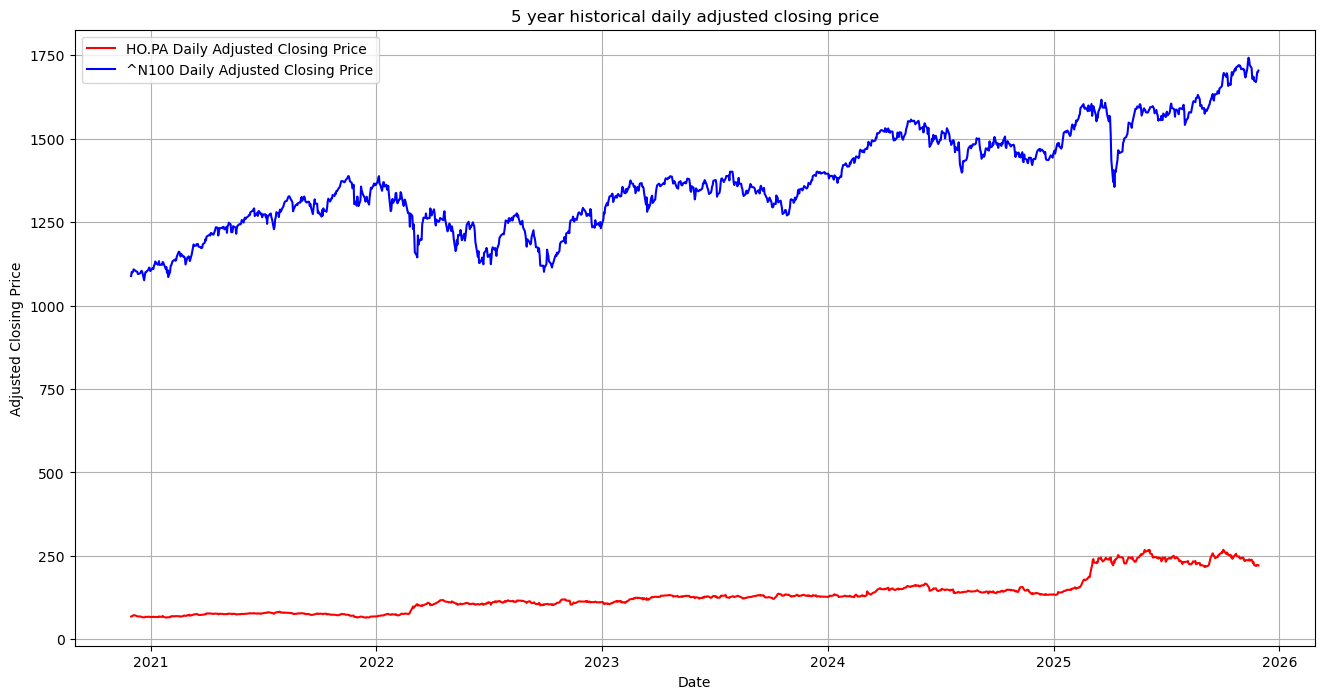

In [9]:
# Importing the data using yfinance
df = pd.DataFrame(yf.download("HO.PA", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()
index = pd.DataFrame(yf.download("^N100", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the data
plt.figure(figsize = (16, 8))
plt.grid(True)
plt.ylabel("Adjusted Closing Price")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price")
plt.plot(df["Adj Close"], label = "HO.PA Daily Adjusted Closing Price", color="red")
plt.plot(index["Adj Close"], label = "^N100 Daily Adjusted Closing Price", color="blue")
plt.legend()
plt.show()

### b) CAPM Analysis

I am going to use OLS regression for CAPM analsysis to get the the CAPM Model Summary table and then plot the results with a line of regression. For this specific purpose I will be using the risk free rate = 3%.

$$E(R_i) = R_f + \beta_i(E(R_m) - R_f)$$

[*********************100%***********************]  2 of 2 completed


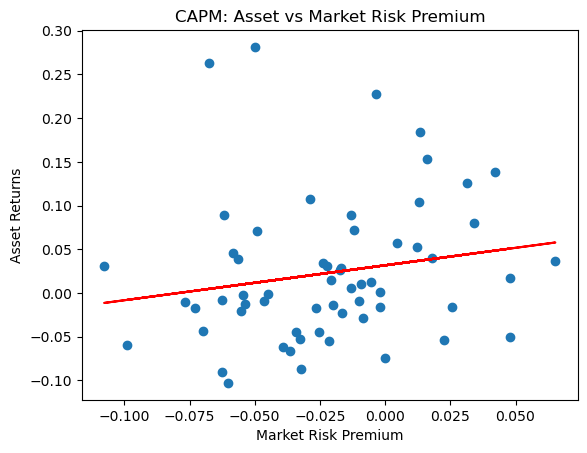

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.938
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.169
Time:                        16:06:14   Log-Likelihood:                 66.282
No. Observations:                  60   AIC:                            -128.6
Df Residuals:                      58   BIC:                            -124.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0317      0.012      2.584      0.0

In [10]:
# Getting Data from Yahoo Finance 
asset_ticker = "HO.PA"
index = "^N100"
df = yf.download([asset_ticker, index], start= "2020-11-30", end= "2025-11-30", auto_adjust=False)[["Adj Close"]].dropna()

# Renaming columns and resampling data from daily to monthly
x = df["Adj Close"].rename(columns={asset_ticker: "asset",
 index: "market"}) \
 .resample("ME") \
 .last() \
 .pct_change() \
 .dropna()

# Defining x and y
y = x.pop("asset")
x["market"] = x["market"] - 0.03
x = sm.add_constant(x)
capm_model = sm.OLS(y, x).fit()


# Plotting market risk premium (x) and asset returns (y)
asset_returns = y
market_risk_premium = x["market"]
plot_x = sm.add_constant(market_risk_premium)
predict_y = capm_model.predict(plot_x)
plt.figure()
plt.scatter(market_risk_premium, asset_returns)
plt.plot(market_risk_premium, predict_y, color="red")
plt.xlabel("Market Risk Premium")
plt.ylabel("Asset Returns")
plt.title("CAPM: Asset vs Market Risk Premium")
plt.show()

print(capm_model.summary())

### CAPM Conclusions

- The asset (HO.PA) shows a positive but statistically insignificant (beta).
- The asset is less volatile and has less systematic risk than the market as a whole, according to the calculated beta of 0.3998.
- We cannot, however, conclude with confidence that the asset's returns have a linear connection with the market's returns because the matching P-value of 0.169 is higher than the conventional 0.05 significance level.
- Only over 3.2% of the variability in the asset's returns can be explained by changes in the market, according to the very low R-square of 0.032.

### c) Fama French 3-Factor Analysis

I am going to conduct Fama French 3-Factor regression analysis. I will retrieve and use Fama French factors using the datareader. For this specific purpose I will be using the risk free rate = 3%.

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,M}(R_{M,t} - R_{f,t}) + \beta_{i,SMB}SMB_t + \beta_{i,HML}HML_t + \epsilon_{i,t}$$

In [11]:
# Getting data from Yahoo Finance
data_monthly = yf.download("HO.PA", start="2020-11-30", end="2025-11-30", interval="1mo", auto_adjust=False)
data_monthly.columns = data_monthly.columns.get_level_values(0)
data_monthly = data_monthly[["Adj Close"]].dropna()

# calculating percentage returns
data_monthly["Return"] = data_monthly["Adj Close"].pct_change() * 100
data_monthly = data_monthly.dropna()

# Retrieving Fama French Factors
ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="2020-11-30", end="2025-11-30")
ff_monthly = ff[0].copy()

# Converting index to datetime and merging datasets
ff_monthly.index = ff_monthly.index.to_timestamp()
merged_data = ff_monthly.merge(data_monthly[["Return"]], left_index=True, right_index=True, how="inner")

# Calculating market risk premium
merged_data["Excess_Return"] = merged_data["Return"] - 0.03

# Regression Analysis
x = sm.add_constant(merged_data[["Mkt-RF", "SMB", "HML"]])
y = merged_data["Excess_Return"]
fama_model = sm.OLS(y, x).fit()

print(fama_model.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1.611
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.197
Time:                        16:06:14   Log-Likelihood:                -205.58
No. Observations:                  59   AIC:                             419.2
Df Residuals:                      55   BIC:                             427.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8467      1.129      1.635      0.1

### Fama French Conclusions

- Just 8.9% (R-squared = 0.089) of the variation in the stock's excess returns explained by the model.
- Additionally, the model's high (F-statistic) of 0.168 (higher than 0.05) indicates that it is not statistically significant overall.
- Crucially, none of the factor coefficients are statistically significant at the 5% level: the Value (HML) factor is 0.4403, the Size (SMB) factor is -0.5173, and the Market factor (Mkt-RF) is close to zero at -0.0194.
- These findings imply that HO.PAs exposure to the systematic market, size, or value risk aspects of the Fama-French model is insufficient to account for its excess returns over this time.

# **5. Analysis for (GALP.LS) Galp Energia**

### a) Importing and plotting price data from Yahoo Finance

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


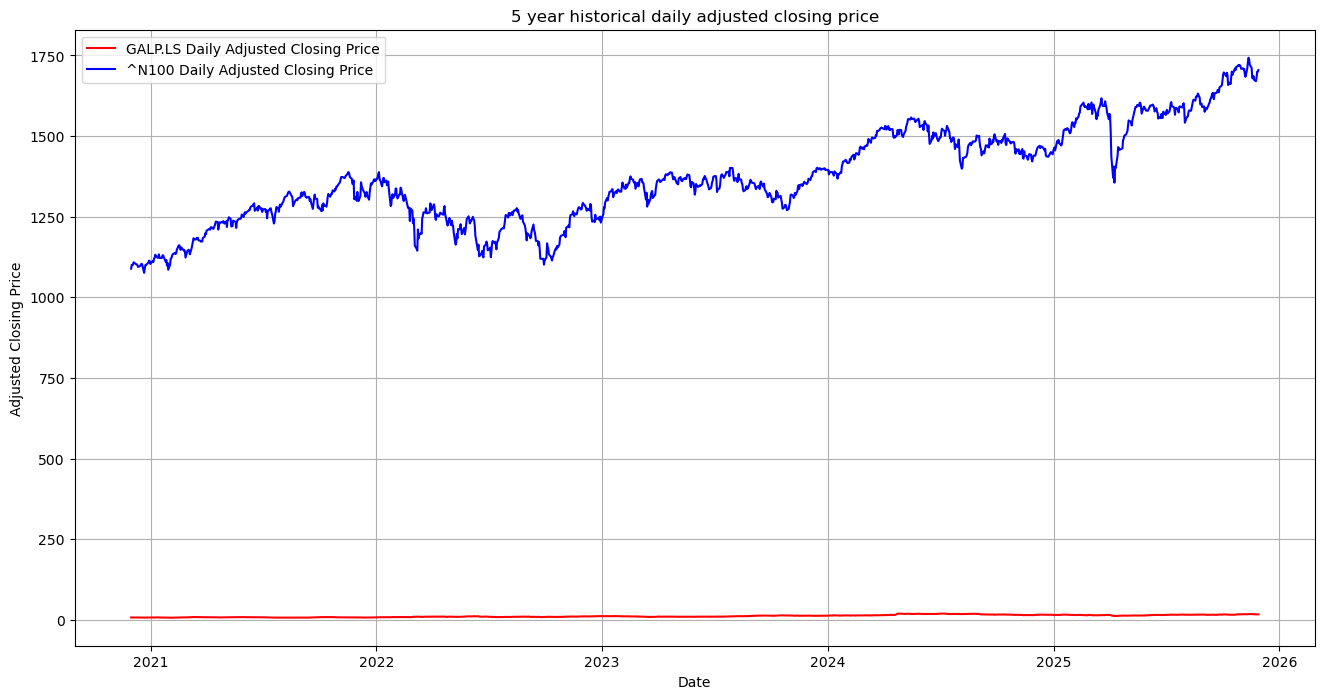

In [12]:
# Importing the data using yfinance
df = pd.DataFrame(yf.download("GALP.LS", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()
index = pd.DataFrame(yf.download("^N100", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the data
plt.figure(figsize = (16, 8))
plt.grid(True)
plt.ylabel("Adjusted Closing Price")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price")
plt.plot(df["Adj Close"], label = "GALP.LS Daily Adjusted Closing Price", color="red")
plt.plot(index["Adj Close"], label = "^N100 Daily Adjusted Closing Price", color="blue")
plt.legend()
plt.show()

### b) CAPM Analysis

I am going to use OLS regression for CAPM analsysis to get the the CAPM Model Summary table and then plot the results with a line of regression. For this specific purpose I will be using the risk free rate = 3%.

$$E(R_i) = R_f + \beta_i(E(R_m) - R_f)$$

[*********************100%***********************]  2 of 2 completed


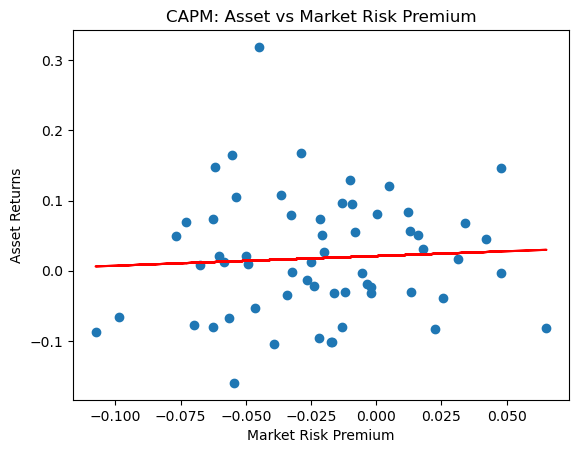

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.2009
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.656
Time:                        16:06:15   Log-Likelihood:                 62.507
No. Observations:                  60   AIC:                            -121.0
Df Residuals:                      58   BIC:                            -116.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0209      0.013      1.602      0.1

In [13]:
# Getting Data from Yahoo Finance 
asset_ticker = "GALP.LS"
index = "^N100"
df = yf.download([asset_ticker, index], start= "2020-11-30", end= "2025-11-30", auto_adjust=False)[["Adj Close"]].dropna()

# Renaming columns and resampling data from daily to monthly
x = df["Adj Close"].rename(columns={asset_ticker: "asset",
 index: "market"}) \
 .resample("ME") \
 .last() \
 .pct_change() \
 .dropna()

# Defining x and y
y = x.pop("asset")
x["market"] = x["market"] - 0.03
x = sm.add_constant(x)
capm_model = sm.OLS(y, x).fit()


# Plotting market risk premium (x) and asset returns (y)
asset_returns = y
market_risk_premium = x["market"]
plot_x = sm.add_constant(market_risk_premium)
predict_y = capm_model.predict(plot_x)
plt.figure()
plt.scatter(market_risk_premium, asset_returns)
plt.plot(market_risk_premium, predict_y, color="red")
plt.xlabel("Market Risk Premium")
plt.ylabel("Asset Returns")
plt.title("CAPM: Asset vs Market Risk Premium")
plt.show()

print(capm_model.summary())

### CAPM Conclusions

- The asset (GALP.LS) shows a positive but statistically insignificant beta.
- The asset is substantially less volatile and has lower systematic risk than the market as a whole, according to the calculated Beta of 0.1371.
- There is no statistical proof of a linear link between the asset's returns and the market's returns because the associated P-value (0.656) is significantly greater than the typical 0.05 significance level.
- The asset's performance is practically just driven by firm-specific (unsystematic) risk, as seen by the very low R2 of 0.003, which shows that market movements account for less than 1% of the variability in the asset's returns.

### c) Fama French 3-Factor Analysis

I am going to conduct Fama French 3-Factor regression analysis. I will retrieve and use Fama French factors using the datareader. For this specific purpose I will be using the risk free rate = 3%.

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,M}(R_{M,t} - R_{f,t}) + \beta_{i,SMB}SMB_t + \beta_{i,HML}HML_t + \epsilon_{i,t}$$

In [14]:
# Getting data from Yahoo Finance
data_monthly = yf.download("GALP.LS", start="2020-11-30", end="2025-11-30", interval="1mo", auto_adjust=False)
data_monthly.columns = data_monthly.columns.get_level_values(0)
data_monthly = data_monthly[["Adj Close"]].dropna()

# calculating percentage returns
data_monthly["Return"] = data_monthly["Adj Close"].pct_change() * 100
data_monthly = data_monthly.dropna()

# Retrieving Fama French Factors
ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="2020-11-30", end="2025-11-30")
ff_monthly = ff[0].copy()

# Converting index to datetime and merging datasets
ff_monthly.index = ff_monthly.index.to_timestamp()
merged_data = ff_monthly.merge(data_monthly[["Return"]], left_index=True, right_index=True, how="inner")

# Calculating market risk premium
merged_data["Excess_Return"] = merged_data["Return"] - 0.03

# Regression Analysis
x = sm.add_constant(merged_data[["Mkt-RF", "SMB", "HML"]])
y = merged_data["Excess_Return"]
fama_model = sm.OLS(y, x).fit()

print(fama_model.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     4.149
Date:                Tue, 09 Jun 2026   Prob (F-statistic):             0.0101
Time:                        16:06:16   Log-Likelihood:                -204.03
No. Observations:                  59   AIC:                             416.1
Df Residuals:                      55   BIC:                             424.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9816      1.100      0.892      0.3

### Fama French Conclusions

- Just 18.8% (R-squared = 0.188) of the stock's excess return fluctuation is explained by this OLS regressiony.
- The model's (F-statistic) of 0.0101 (less than 0.05) indicates that it is statistically significant overall.
- A mixed picture emerges when the individual elements are examined: The Market factor (Mkt-RF) coefficient is not statistically significant and is near zero at 0.0800, indicating that there is little correlation between Galp's returns and the overall market movements during this time.
- Likewise, the -0.5800 Size (SMB) factor coefficient is not statistically significant. On the other hand, Galp's excess returns considerably burden on the value factor throughout this period, as seen by the Value (HML) factor's highly statistically significant coefficient of 0.7995.

# **6. Analysis for (IPN.PA) Ipsen S.A.**

### a) Importing and plotting price data from Yahoo Finance

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


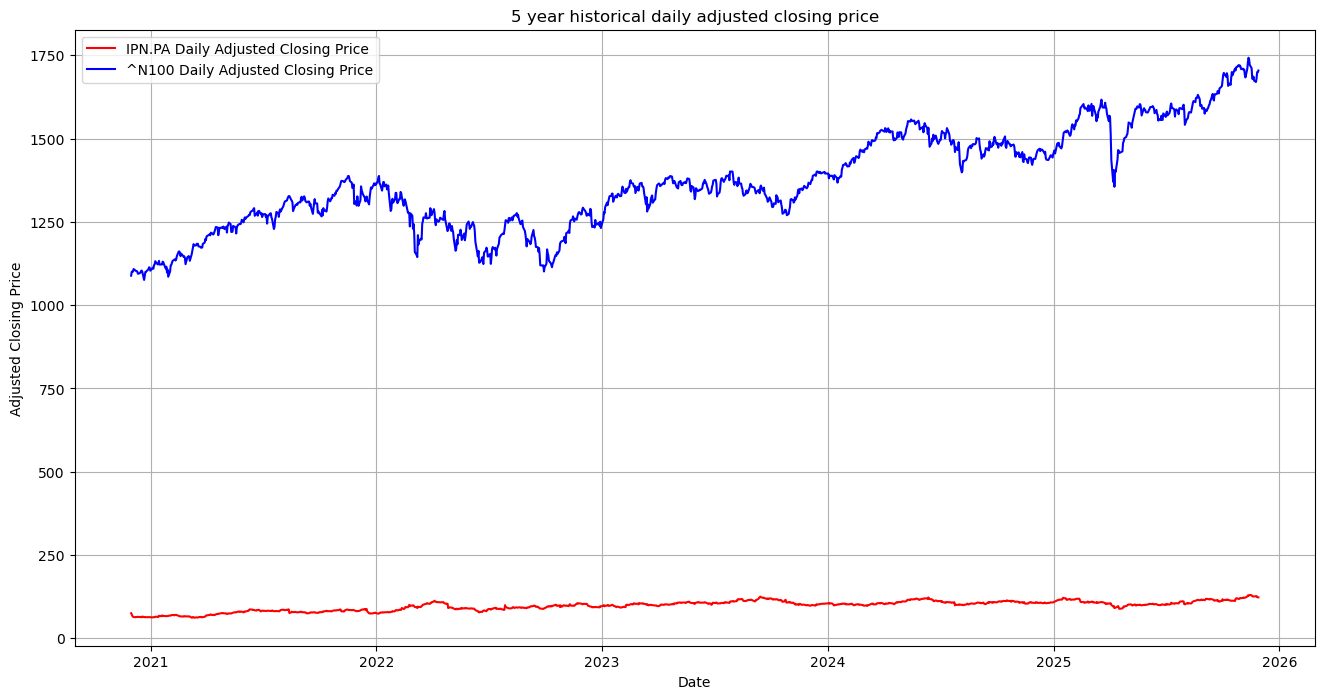

In [15]:
# Importing the data using yfinance
df = pd.DataFrame(yf.download("IPN.PA", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()
index = pd.DataFrame(yf.download("^N100", start = "2020-11-30", end = "2025-11-30", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the data
plt.figure(figsize = (16, 8))
plt.grid(True)
plt.ylabel("Adjusted Closing Price")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price")
plt.plot(df["Adj Close"], label = "IPN.PA Daily Adjusted Closing Price", color="red")
plt.plot(index["Adj Close"], label = "^N100 Daily Adjusted Closing Price", color="blue")
plt.legend()
plt.show()

### b) CAPM Analysis

I am going to use OLS regression for CAPM analsysis to get the the CAPM Model Summary table and then plot the results with a line of regression. For this specific purpose I will be using the risk free rate = 3%.

$$E(R_i) = R_f + \beta_i(E(R_m) - R_f)$$

[*********************100%***********************]  2 of 2 completed


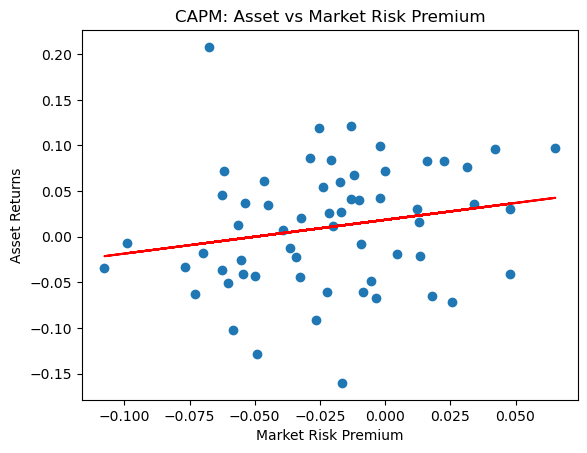

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.441
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.124
Time:                        16:06:16   Log-Likelihood:                 77.853
No. Observations:                  60   AIC:                            -151.7
Df Residuals:                      58   BIC:                            -147.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0185      0.010      1.833      0.0

In [16]:
# Getting Data from Yahoo Finance 
asset_ticker = "IPN.PA"
index = "^N100"
df = yf.download([asset_ticker, index], start= "2020-11-30", end= "2025-11-30", auto_adjust=False)[["Adj Close"]].dropna()

# Renaming columns and resampling data from daily to monthly
x = df["Adj Close"].rename(columns={asset_ticker: "asset",
 index: "market"}) \
 .resample("ME") \
 .last() \
 .pct_change() \
 .dropna()

# Defining x and y
y = x.pop("asset")
x["market"] = x["market"] - 0.03
x = sm.add_constant(x)
capm_model = sm.OLS(y, x).fit()


# Plotting market risk premium (x) and asset returns (y)
asset_returns = y
market_risk_premium = x["market"]
plot_x = sm.add_constant(market_risk_premium)
predict_y = capm_model.predict(plot_x)
plt.figure()
plt.scatter(market_risk_premium, asset_returns)
plt.plot(market_risk_premium, predict_y, color="red")
plt.xlabel("Market Risk Premium")
plt.ylabel("Asset Returns")
plt.title("CAPM: Asset vs Market Risk Premium")
plt.show()

print(capm_model.summary())

### CAPM Conclusions

- The asset (IPN.PA) has a positive but statistically negligible beta.
- The asset is less volatile and bears less systematic risk than the market as a whole, according to the calculated beta of 0.3700.
- We cannot deduce with 95% confidence that the asset's returns are linearly connected to the market's returns because the associated P-value of 0.124 is higher than the conventional 0.05 significance level.
- The majority of the asset's risk is firm-specific (unsystematic), as indicated by the R2 of 0.040, which shows that only around 4% of the variability in the asset's returns can be explained by market movements.

### c) Fama French 3-Factor Analysis

I am going to conduct Fama French 3-Factor regression analysis. I will retrieve and use Fama French factors using the datareader. For this specific purpose I will be using the risk free rate = 3%.

$$R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,M}(R_{M,t} - R_{f,t}) + \beta_{i,SMB}SMB_t + \beta_{i,HML}HML_t + \epsilon_{i,t}$$

In [17]:
# Getting data from Yahoo Finance
data_monthly = yf.download("IPN.PA", start="2020-11-30", end="2025-11-30", interval="1mo", auto_adjust=False)
data_monthly.columns = data_monthly.columns.get_level_values(0)
data_monthly = data_monthly[["Adj Close"]].dropna()

# calculating percentage returns
data_monthly["Return"] = data_monthly["Adj Close"].pct_change() * 100
data_monthly = data_monthly.dropna()

# Retrieving Fama French Factors
ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start="2020-11-30", end="2025-11-30")
ff_monthly = ff[0].copy()

# Converting index to datetime and merging datasets
ff_monthly.index = ff_monthly.index.to_timestamp()
merged_data = ff_monthly.merge(data_monthly[["Return"]], left_index=True, right_index=True, how="inner")

# Calculating market risk premium
merged_data["Excess_Return"] = merged_data["Return"] - 0.03

# Regression Analysis
x = sm.add_constant(merged_data[["Mkt-RF", "SMB", "HML"]])
y = merged_data["Excess_Return"]
fama_model = sm.OLS(y, x).fit()

print(fama_model.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9980
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.401
Time:                        16:06:17   Log-Likelihood:                -192.03
No. Observations:                  59   AIC:                             392.1
Df Residuals:                      55   BIC:                             400.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9845      0.898      1.097      0.2

### Fama French Conclusions

- The model explains around 69.8% (R-squared = 0.698) of the variation in the stock's excess returns.
- The model's near-zero (F-statistic) of 1.52×10−11 indicates that it is statistically significant overall.
- The stock's volatility is somewhat greater than the market average, as shown by the statistically significant Market factor (Mkt-RF) coefficient of 1.0963 (a beta close to 1.1).
- The High (SMB) factor coefficient of 0.7811 indicates that the stock exhibits strong small-cap stock behavior.
- Lastly, the company performs like a growth stock (low book-to-market ratio) throughout this time, as shown by the Value (HML) factor, which is statistically significant at -0.5739 with a negative sign.